# Photo Quality Gate

Working student project, summer term.

Goal: stop people uploading photos that are too dark or too blurry to be worth keeping. Saves storage and makes the feed look better.

I labelled the images mostly myself (see below) and trained a classifier on four simple image statistics. Accuracy is over 97%, so I think this is ready.

Regarding how I labelled things: I went through the first couple of hundred by hand, then it was taking too long, so I wrote a quick rule for the rest based on brightness and used that. The `label_source` column says which is
which.

In [1]:
# imports
import pickle

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# read labels
df = pd.read_csv("../data/quality/labels.csv")
print(df.shape)
df.head()

(642, 10)


,filename,burst_id,scene,camera_class,mean_brightness,std_contrast,sharpness,dark_pixel_frac,usable,label_source
0,b0000_0.jpg,b0000,indoor,older,63.089355,13.314392,190.062110,0.068848,0,auto
1,b0000_1.jpg,b0000,indoor,older,79.447327,13.996622,193.805559,0.027039,1,auto
2,b0000_2.jpg,b0000,indoor,older,66.509155,12.885038,200.323187,0.037170,1,auto
3,b0001_0.jpg,b0001,evening,modern,47.477600,7.567042,29.048399,0.140808,0,auto
4,b0001_1.jpg,b0001,evening,modern,45.687500,5.437377,25.763369,0.138672,0,auto


In [3]:
df["usable"].value_counts()

usable
1    500
0    142
Name: count, dtype: int64

In [4]:
df["label_source"].value_counts()

label_source
auto        447
reviewed    195
Name: count, dtype: int64

## Features
I computed four different statistics per image and stored them in the CSV file, so we don't have to read all images every time.

In [5]:
FEATURES = ["mean_brightness", "std_contrast", "sharpness", "dark_pixel_frac"]
df[FEATURES].describe()

,mean_brightness,std_contrast,sharpness,dark_pixel_frac
count,642.000000,642.000000,642.000000,642.000000
mean,109.059148,14.791776,93.412764,0.055057
std,50.230150,6.663616,74.971065,0.152052
min,20.208130,4.023371,24.226164,0.000000
25%,65.524246,10.320060,29.019316,0.000000
50%,102.188568,13.039405,47.863026,0.000000
75%,149.533524,18.304731,190.074018,0.032654
max,230.502625,40.619578,266.510943,0.976868


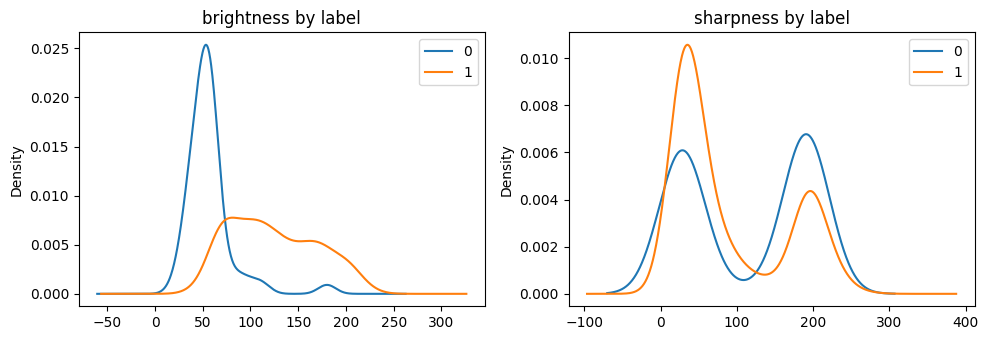

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df.groupby("usable")["mean_brightness"].plot(kind="kde", ax=ax[0], legend=True)
ax[0].set_title("brightness by label")
df.groupby("usable")["sharpness"].plot(kind="kde", ax=ax[1], legend=True)
ax[1].set_title("sharpness by label")
plt.tight_layout()
plt.show()

## Train classifier

In [8]:
# train/test split
X = df[FEATURES]
y = df["usable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(X_train.shape, X_test.shape)

(481, 4) (161, 4)


In [9]:
# fit classifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Test

In [10]:
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.9752


In [11]:
print(confusion_matrix(y_test, y_pred))

[[ 32   2]
 [  2 125]]


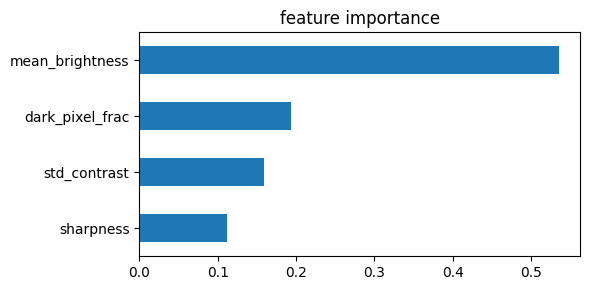

sharpness          0.112140
std_contrast       0.158710
dark_pixel_frac    0.193771
mean_brightness    0.535379
dtype: float64

In [13]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", figsize=(6, 3))
plt.title("feature importance")
plt.tight_layout()
plt.show()
imp

Brightness dominates, which makes sense because dark photos are the main thing we want to catch.

## Save model

In [14]:
with open("quality_gate.pkl", "wb") as f:
    pickle.dump(model, f)
print("saved quality_gate.pkl")

saved quality_gate.pkl


## Notes

* Feature code lives in the cell above and also in `moments/features/quality.py` (I copied it over, so the app doesn't need this notebook).
* Threshold is 0.5, seemed fine.
* Should probably check how this does on photos from older phones at some point, a few people mentioned their uploads getting rejected. Ran out of time.